In [81]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
df=pd.read_csv('customer_behavior_dataset.csv')
df.drop(columns=['CustomerID', 'Membership'],inplace=True)
df

,Age,Gender,Annual_Income_kUSD,Region,Platform,Product_Preference,Visits_per_Month,Time_Spent_per_Visit_min,Pages_Visited_per_Session,Previous_Purchases,Avg_Purchase_Value_USD,Total_Purchase_Value_USD,Days_Since_Last_Purchase,Made_Purchase_Last_Month,Will_Purchase_Next_Month,Next_Month_Spend_USD
0,40,Male,40.58,Central,Mobile,Apparel,5,6.0,5,1,NaN,42.43,0,0,0,0.00
1,33,Male,53.20,West,Mobile,Apparel,3,9.0,2,0,25.95,0.00,206,0,0,0.00
2,42,Female,73.70,West,Mobile,Home & Kitchen,3,13.9,2,0,71.06,13.92,15,0,0,0.00
3,51,Female,45.95,East,Mobile,Sports,3,1.0,4,1,35.81,91.43,149,0,0,0.00
4,32,Male,45.32,East,Mobile,Apparel,11,11.1,7,3,5.00,37.75,6,1,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,Male,89.67,North,Mobile,Beauty,11,15.5,7,2,35.09,24.33,68,1,0,0.00
996,54,Male,97.17,Central,Mobile,Electronics,1,2.2,5,0,155.15,0.00,14,0,0,0.00
997,42,Female,33.47,South,Mobile,Apparel,6,4.3,8,6,34.29,298.47,2,0,0,0.00
998,28,Male,100.57,Central,Mobile,Electronics,7,16.9,8,3,118.26,411.34,9,1,1,57.64


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   Gender                     970 non-null    object 
 2   Annual_Income_kUSD         1000 non-null   float64
 3   Region                     1000 non-null   object 
 4   Platform                   1000 non-null   object 
 5   Product_Preference         1000 non-null   object 
 6   Visits_per_Month           1000 non-null   int64  
 7   Time_Spent_per_Visit_min   940 non-null    float64
 8   Pages_Visited_per_Session  1000 non-null   int64  
 9   Previous_Purchases         1000 non-null   int64  
 10  Avg_Purchase_Value_USD     960 non-null    float64
 11  Total_Purchase_Value_USD   1000 non-null   float64
 12  Days_Since_Last_Purchase   1000 non-null   int64  
 13  Made_Purchase_Last_Month   1000 non-null   int64 

In [84]:
df.isnull().any()

Age                          False
Gender                        True
Annual_Income_kUSD           False
Region                       False
Platform                     False
Product_Preference           False
Visits_per_Month             False
Time_Spent_per_Visit_min      True
Pages_Visited_per_Session    False
Previous_Purchases           False
Avg_Purchase_Value_USD        True
Total_Purchase_Value_USD     False
Days_Since_Last_Purchase     False
Made_Purchase_Last_Month     False
Will_Purchase_Next_Month     False
Next_Month_Spend_USD         False
dtype: bool

In [85]:
df['Gender']=df['Gender'].fillna(df['Gender'].median)
df['Time_Spent_per_Visit_min']=df['Time_Spent_per_Visit_min'].fillna(df['Time_Spent_per_Visit_min'].median)
df['Avg_Purchase_Value_USD']=df['Avg_Purchase_Value_USD'].fillna(df['Avg_Purchase_Value_USD'].median)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   Gender                     1000 non-null   object 
 2   Annual_Income_kUSD         1000 non-null   float64
 3   Region                     1000 non-null   object 
 4   Platform                   1000 non-null   object 
 5   Product_Preference         1000 non-null   object 
 6   Visits_per_Month           1000 non-null   int64  
 7   Time_Spent_per_Visit_min   1000 non-null   object 
 8   Pages_Visited_per_Session  1000 non-null   int64  
 9   Previous_Purchases         1000 non-null   int64  
 10  Avg_Purchase_Value_USD     1000 non-null   object 
 11  Total_Purchase_Value_USD   1000 non-null   float64
 12  Days_Since_Last_Purchase   1000 non-null   int64  
 13  Made_Purchase_Last_Month   1000 non-null   int64 

In [86]:
x=df.drop(columns='Next_Month_Spend_USD')
y=df.Next_Month_Spend_USD

In [87]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

In [88]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

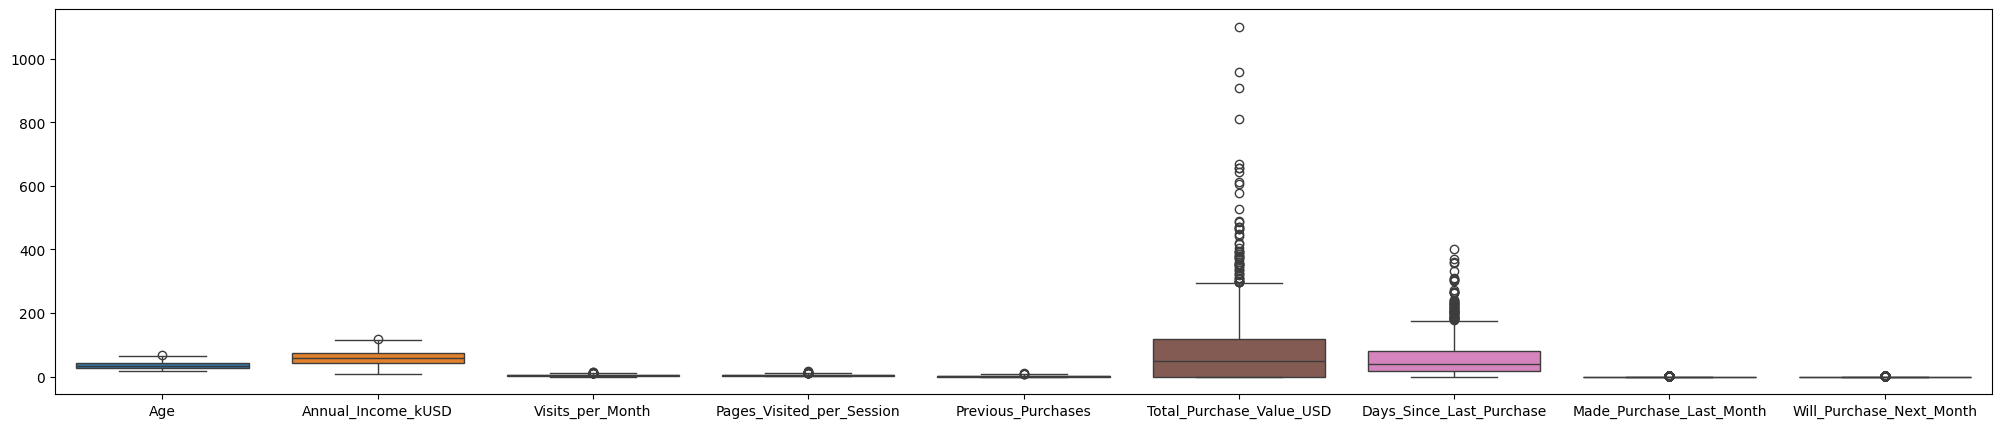

In [89]:
plt.figure(figsize=(25,5))
sns.boxplot(data=xtrain[num_cols])
plt.show()

In [90]:
xtrain[obj_cols].nunique()

Gender                        3
Region                        5
Platform                      3
Product_Preference            6
Time_Spent_per_Visit_min    178
Avg_Purchase_Value_USD      647
dtype: int64

In [91]:
preprocessing=ColumnTransformer(
    transformers=[
        ('standard_scaler', StandardScaler(),['Age', 'Annual_Income_kUSD', 'Visits_per_Month',
       'Time_Spent_per_Visit_min', 'Pages_Visited_per_Session',
       'Previous_Purchases','Made_Purchase_Last_Month', 'Will_Purchase_Next_Month']),
       ('robust_scaler',RobustScaler(), ['Avg_Purchase_Value_USD',
       'Total_Purchase_Value_USD', 'Days_Since_Last_Purchase'] ),
       ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Gender', 'Region', 'Platform', 'Product_Preference'])
    ],
    remainder='passthrough'
)

In [92]:
main_pipeline=Pipeline(
    steps=[
        ('preprocessing', preprocessing),
        ('model', KNeighborsRegressor(n_neighbors=5))
    ]
)

In [93]:
main_pipeline.fit(xtrain,ytrain)

TypeError: float() argument must be a string or a real number, not 'method'